# Regressão com Regularização L2 (Ridge)

Nesse notebook iremos treinar um modelo de regressão com regularização L2, também conhecido como Ridge e iremos comparar seus resultados com o baseline.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [9]:
df = pd.read_parquet("../../data/processed/03_processed.parquet")

In [10]:
df = df.convert_dtypes()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   tipo_imovel                       7919 non-null   string  
 1   preco                             7919 non-null   Int64   
 2   condominio                        4602 non-null   Int64   
 3   area_m2                           7919 non-null   Int64   
 4   quartos                           7918 non-null   Int64   
 5   banheiros                         7918 non-null   Int64   
 6   vagas                             7286 non-null   Int64   
 7   piscina                           7919 non-null   boolean 
 8   espaco_gourmet                    7919 non-null   boolean 
 9   academia                          7919 non-null   boolean 
 10  spa_massagem                      7919 non-null   boolean 
 11  espaco_lazer                      7919 non-null   boolean 
 12  are

In [12]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,distancia_aeroporto_km,faixa_area,faixa_condominio,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,16.213545,pequeno,medio,30.0,30.0,0.033333,0.033333,1.0,2.0,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,7.250204,pequeno,NaN,37.0,37.0,0.027027,0.027027,1.0,1.0,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,8.381749,medio,alto,25.0,41.666667,0.04,0.024,1.666667,1.5,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,8.824588,grande,alto,61.0,81.333333,0.016393,0.012295,1.333333,0.75,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,9.267687,pequeno,medio,28.5,28.5,0.035088,0.035088,1.0,2.0,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,4.911235,pequeno,NaN,27.5,27.5,0.036364,0.036364,1.0,2.0,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,9.094186,pequeno,baixo,52.0,52.0,0.019231,0.019231,1.0,<NA>,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,6.613218,medio,NaN,42.666667,42.666667,0.023438,0.023438,1.0,1.5,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,7.747091,medio,alto,26.25,35.0,0.038095,0.028571,1.333333,1.5,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,3.412207,pequeno,baixo,27.5,27.5,0.036364,0.036364,1.0,2.0,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [13]:
from sklearn.model_selection import train_test_split
from utils import random_state

X = df.drop("preco", axis="columns")
y = df["preco"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=random_state,
)

## Modelagem

O primeiro modelo que iremos treinar será o nosso baseline, uma regressão linear múltipla. Vamos inicialmente separar as features do nosso dataset baseado nos tipos delas.

In [14]:
discrete_columns = ["quartos", "banheiros", "vagas"]

continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["Int64", "Float64"])
    .columns
    .to_list()
)

ordinal_columns = (X_train
    .select_dtypes(include=["category"])
    .columns
    .to_list()
)

categorical_columns = (X_train
    .select_dtypes(include="string")
    .columns
    .to_list()
)

boolean_columns = (X_train
    .select_dtypes(include="boolean")
    .columns
    .to_list()
)

Agora, vamos montar o nosso pipeline de treinamento para a regressão linear.

In [55]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.pipeline import Pipeline

from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer

def get_ridge_regression_pipeline(parameters):
    imputer = SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clipper", Winsorizer(
            capping_method="quantiles",
            fold=parameters["discrete_fold"],
        )),
        ("scaler", StandardScaler())
    ])

    continuous_pipeline = Pipeline(steps=[
        ("imputer", imputer),
        ("clipper", Winsorizer(
            capping_method="quantiles",
            fold=parameters["continuous_fold"],
        )),
        ("normalizer", YeoJohnsonTransformer(
            variables=["condominio", "area_m2"]
        )),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])


    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            ("discrete", discrete_pipeline, discrete_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
            ("boolean", boolean_pipeline, boolean_columns),
        ],
        remainder="drop",
    )

    regressor = Ridge(
        alpha=parameters["alpha"],
        random_state=random_state,
    )

    transformer = QuantileTransformer(
        output_distribution="normal",
        random_state=random_state,
    )

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline

def get_ridge_regression_parameters(trial):
    return {
        "alpha": trial.suggest_float("alpha", 1e-3, 1e3, log=True),
        "continuous_fold": trial.suggest_float("continuous_fold", 1e-3, 1e-2, log=True),
        "discrete_fold": trial.suggest_float("discrete_fold", 1e-3, 1e-2, log=True),
    }

In [56]:
import utils

study = utils.get_study(
    get_pipeline=get_ridge_regression_pipeline,
    get_parameters=get_ridge_regression_parameters,
    X_train=X_train,
    y_train=y_train,
    n_trials=100
)

[I 2026-08-23 00:14:15,195] A new study created in memory with name: no-name-b8fdfd83-f71b-4ead-b414-9e793ad1c918
Best trial: 0. Best value: -937779:   1%|          | 1/100 [00:01<01:39,  1.01s/it]

[I 2026-08-23 00:14:16,201] Trial 0 finished with value: -937779.3819237227 and parameters: {'alpha': 233.53148753974796, 'continuous_fold': 0.001233836901765792, 'discrete_fold': 0.0023241627565418546}. Best is trial 0 with value: -937779.3819237227.


Best trial: 1. Best value: -920390:   2%|▏         | 2/100 [00:01<01:36,  1.02it/s]

[I 2026-08-23 00:14:17,166] Trial 1 finished with value: -920390.0771636569 and parameters: {'alpha': 0.0010331268184365766, 'continuous_fold': 0.0028131734687009786, 'discrete_fold': 0.005335074892157123}. Best is trial 1 with value: -920390.0771636569.


Best trial: 2. Best value: -912480:   3%|▎         | 3/100 [00:02<01:35,  1.01it/s]

...

[I 2026-08-23 00:15:53,359] Trial 97 finished with value: -912121.0231005931 and parameters: {'alpha': 0.1056045121856556, 'continuous_fold': 0.001045075785996194, 'discrete_fold': 0.002282795299693367}. Best is trial 37 with value: -909407.6390727587.


Best trial: 37. Best value: -909408:  99%|█████████▉| 99/100 [01:39<00:00,  1.05it/s]

[I 2026-08-23 00:15:54,355] Trial 98 finished with value: -912454.6575179339 and parameters: {'alpha': 0.04568450900915565, 'continuous_fold': 0.0012406468049880961, 'discrete_fold': 0.0020695975598000343}. Best is trial 37 with value: -909407.6390727587.


Best trial: 37. Best value: -909408: 100%|██████████| 100/100 [01:40<00:00,  1.00s/it]

[I 2026-08-23 00:15:55,348] Trial 99 finished with value: -920954.3038621846 and parameters: {'alpha': 0.014807550054599323, 'continuous_fold': 0.0011434470110481914, 'discrete_fold': 0.004556045282800311}. Best is trial 37 with value: -909407.6390727587.


In [57]:
utils.report_scores(
    get_pipeline=get_ridge_regression_pipeline,
    study=study,
    X_test=X_test,
    y_test=y_test
)

R2: 0.61
RMSE: R$ 917675.16
MAE: R$ 385657.22
MedAE: R$ 133677.61
MAPE: 0.28%


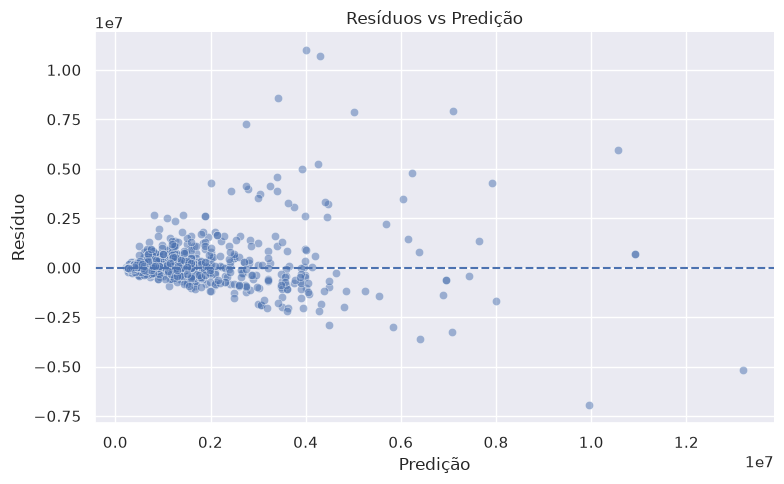

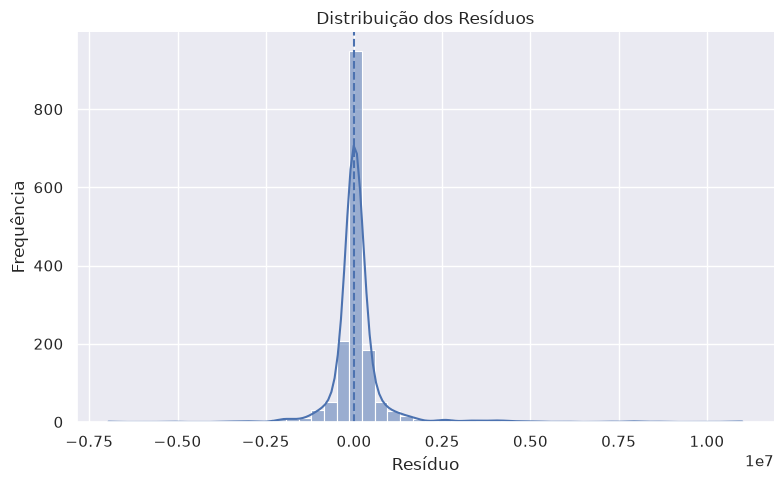

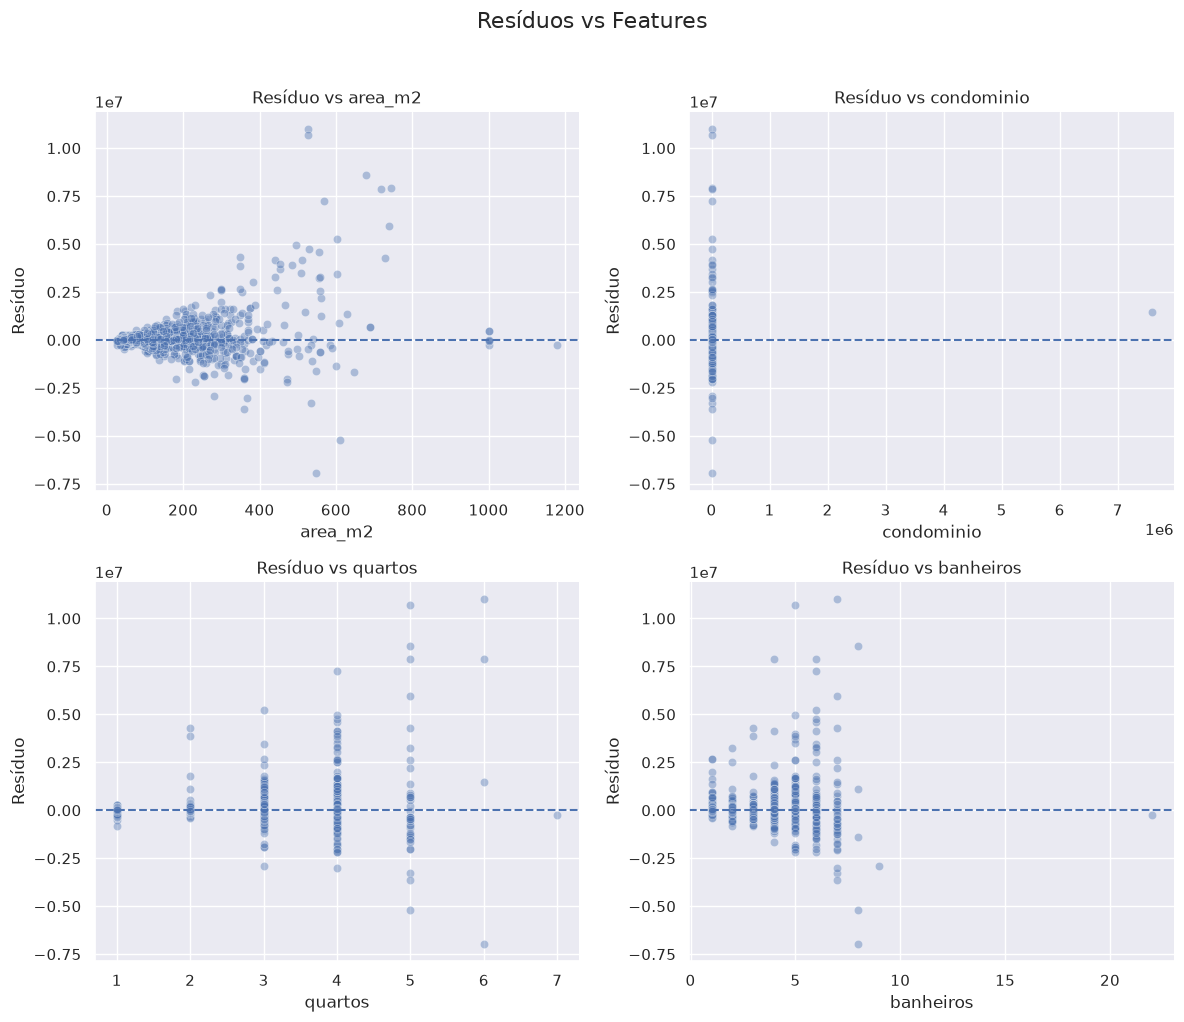

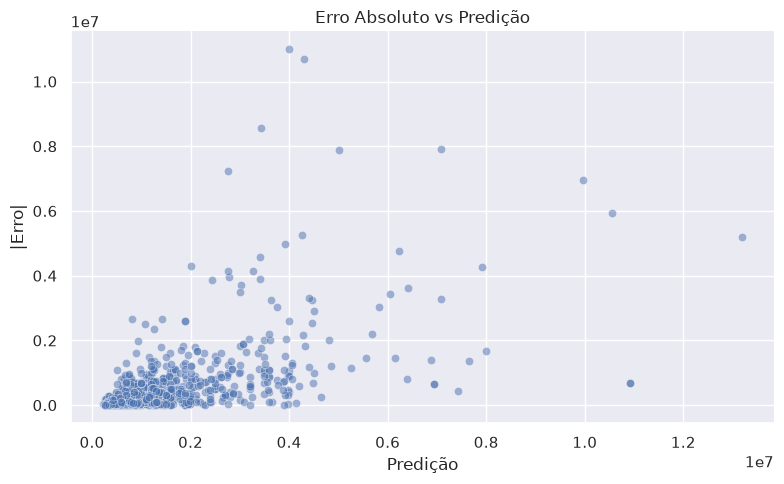


=== Erro Relativo Absoluto ===
count      1584.0
mean     0.266635
std      0.341403
min           0.0
25%      0.090432
50%      0.181818
75%      0.330884
max      4.679521
Name: absolute_relative_error, dtype: Float64

=== 20 Maiores Erros Absolutos ===
     tipo_imovel  condominio  area_m2  quartos  banheiros  vagas  piscina  espaco_gourmet  academia  spa_massagem  espaco_lazer  area_trabalho  espaco_infantil  area_esportiva  portaria  seguranca  servicos_garagem  acessibilidade   pets  varanda  area_verde  espaco_natural  acabamento_premium  moveis_embutidos  layout_premium  cozinha  servicos  conforto_interno  mobiliado  casa_inteligente  servicos_conectividade  infra_energetica  infra_hidrica  servicos_sustentaveis   latitude  longitude  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_setor_central_km  distancia_setor_bueno_km  distancia_setor_marista_km  distancia_jardim_goias_km  distancia_aeroporto_km    faixa_area f

In [58]:
linear_regression_error_df = utils.get_residual_analysis(
    get_pipeline=get_ridge_regression_pipeline,
    study=study,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)